In [2]:
# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lotte van Mispelaar
* Username: lkmispelaar
* Student number: S6394973
* Group (AS1, etc.): AS2

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

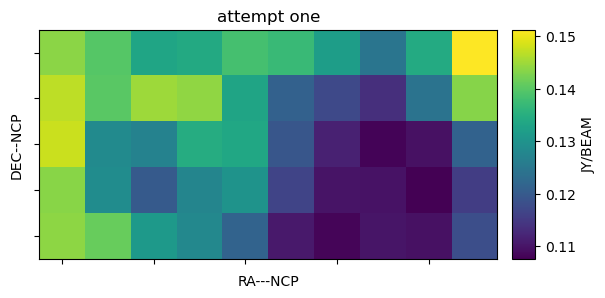

/tmp/ipykernel_1641068/2886939265.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(im, cax = colbarframe, label = hdr['BUNIT'])


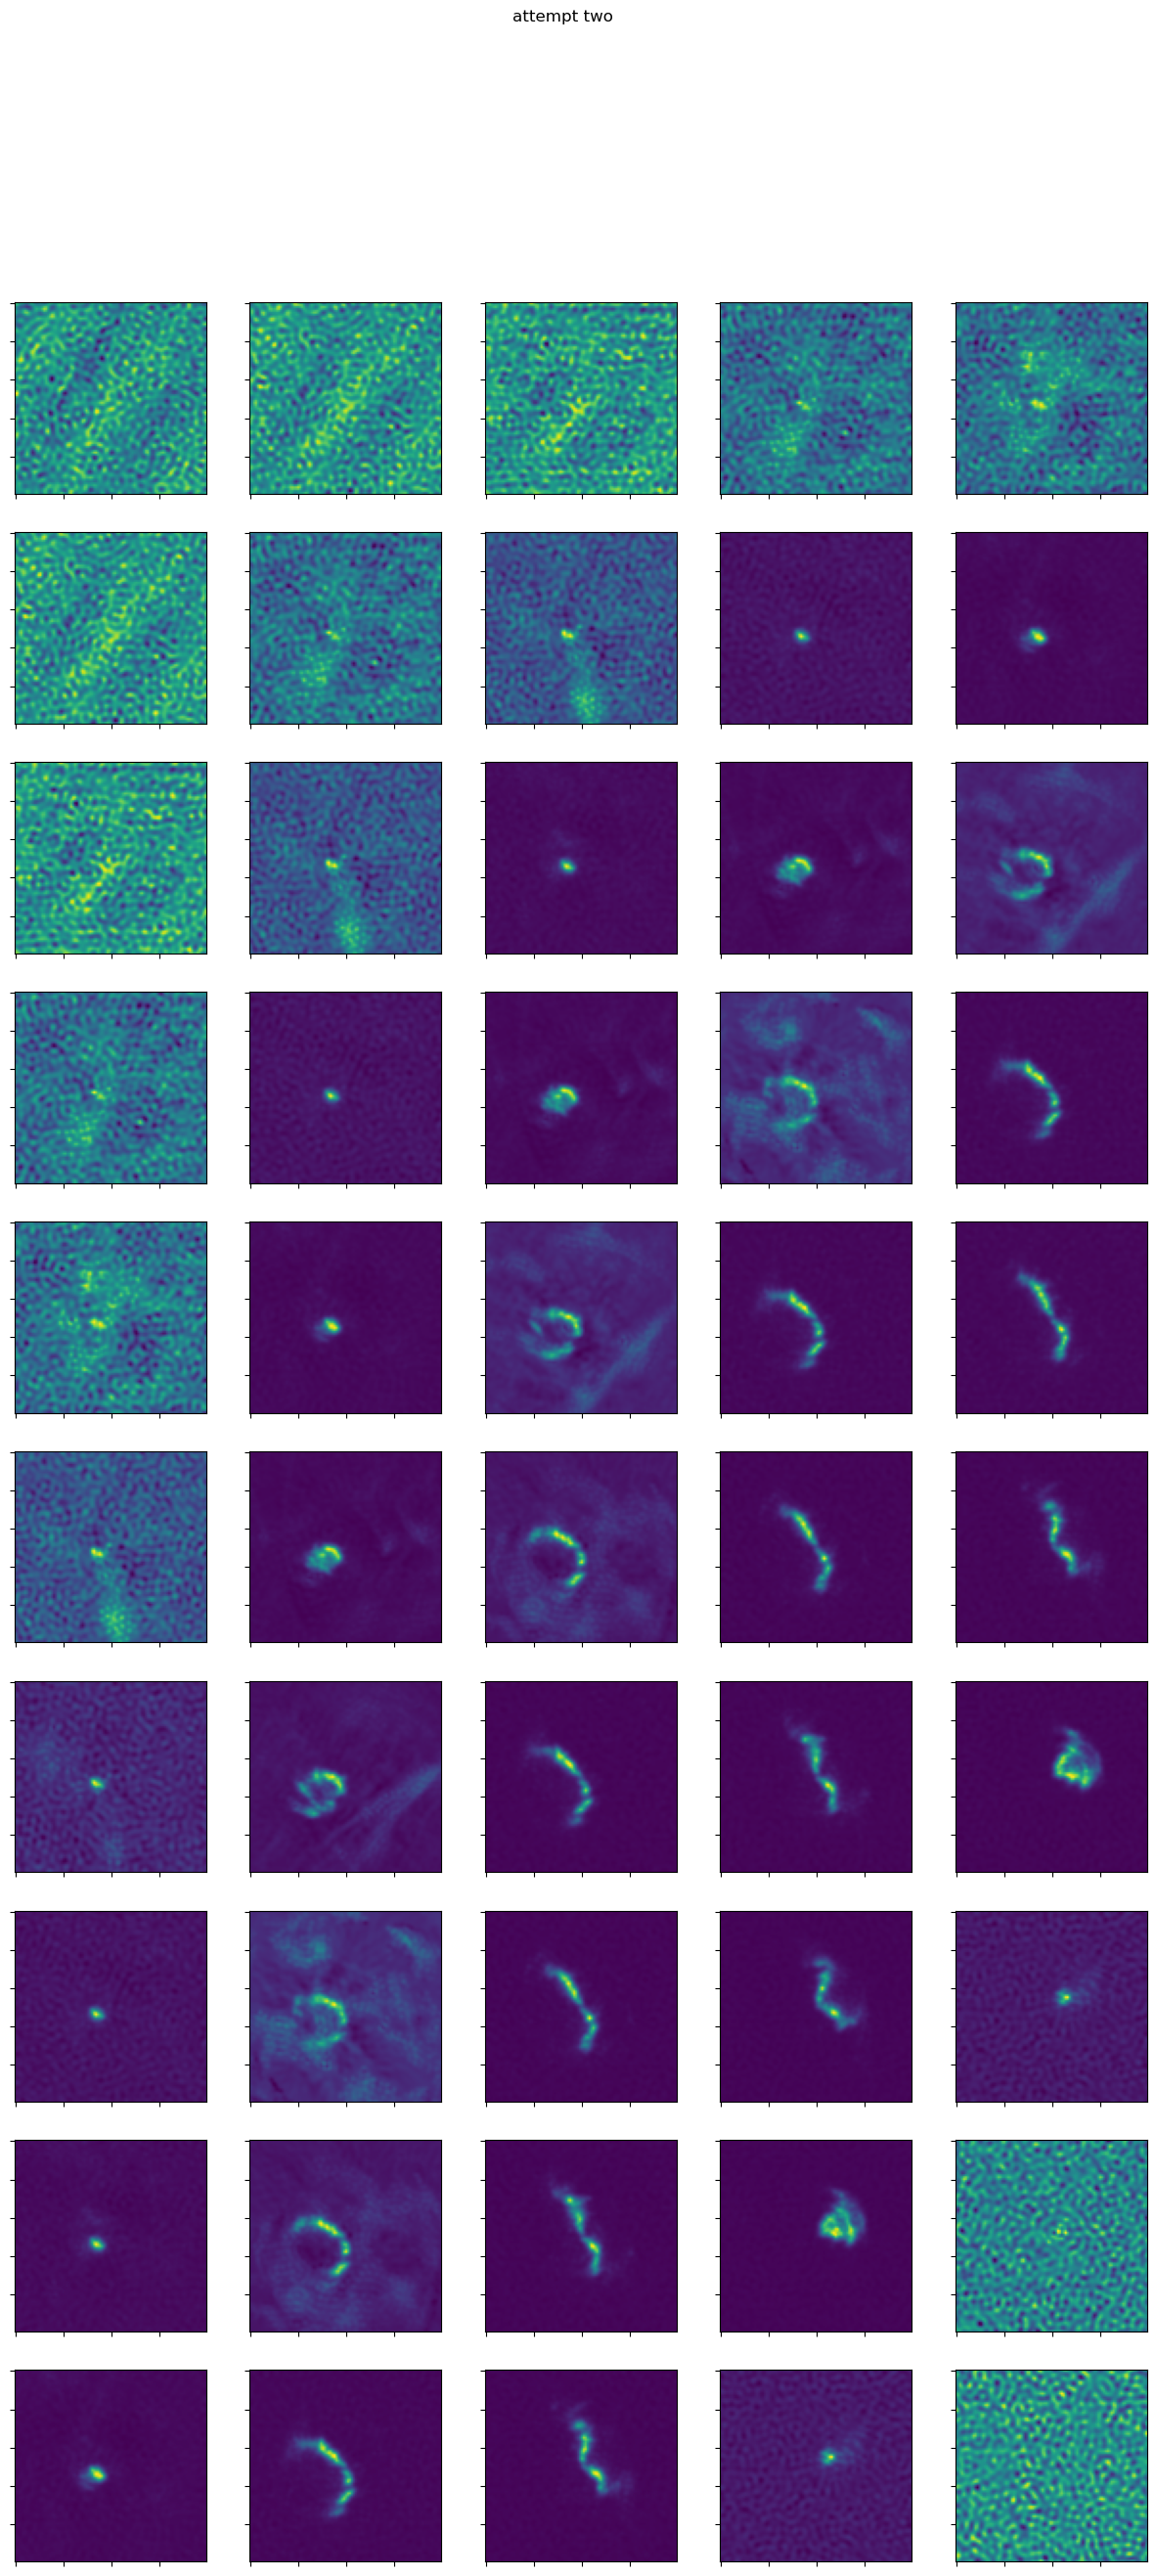

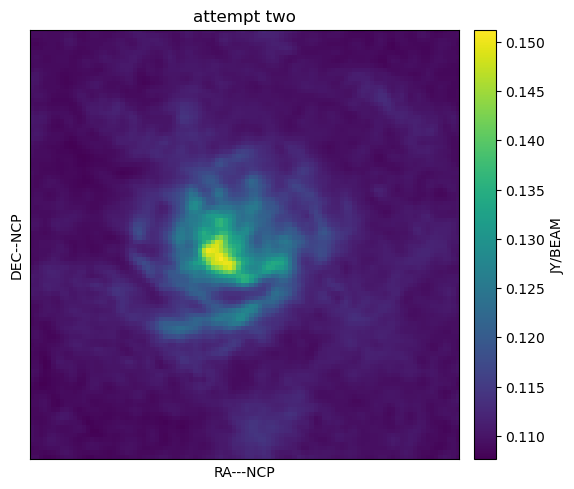

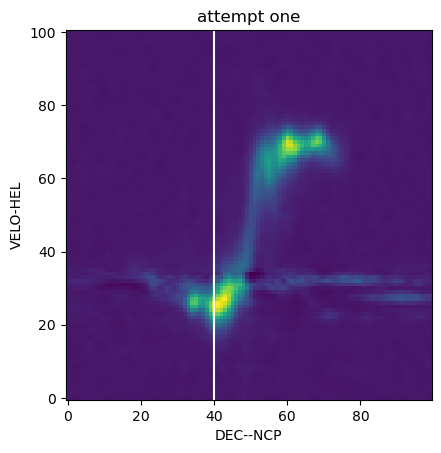

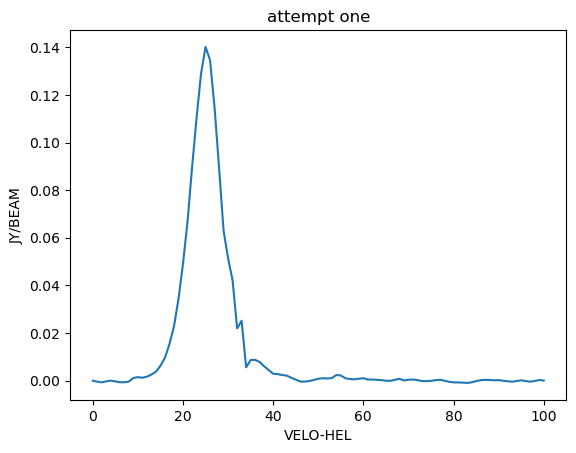

In [41]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import matplotlib.axes as axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

z_indices = range(1, 101, 2)

hdulist = fits.open('ngc6946.fits')
hdr = hdulist[0].header
dat = hdulist[0].data

# total HI map
# To reduce noise I picked the middle of the image
data = np.asarray(dat)[:, 47:52, 45:55]
fig, ax = plt.subplots(1, 1)
# I picked datapoints with steps of 10
im = plt.imshow(data[0] + data[10] + data[20] + data[30] + data[40] + data[50] + data[60] + data[70] + data[80] + data[90] + data[100])
ax = plt.gca()
ax.set_title('attempt one')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])
# colorbar:
divider = make_axes_locatable(ax)
colbarframe = divider.append_axes('right', size = '5%', pad = 0.15)
fig.colorbar(im, cax = colbarframe, label = hdr['BUNIT'])
plt.show()

# I didn't understand what you meant by mosaic so I did it both as a pixel plot aswell as a bunch of subplots
total = 0
data = np.asarray(dat)
fig, ax = plt.subplots(10, 5, figsize = (15, 30))
fig.suptitle('attempt two')
for i in range(0, 10):
    for j in range(0, 5):
        ax[i, j].imshow(data[(i + 1) * (j + 1) * 2 - 1, :, :])
        ax[i, j].set_xticklabels([])
        ax[i, j].set_yticklabels([])
        total += data[(i + 1) * (j + 1) * 2 - 1, :, :]
fig, ax = plt.subplots(1, 1)
ax.set_title('attempt two')
ax.imshow(total)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
divider = make_axes_locatable(ax)
colbarframe = divider.append_axes('right', size = '5%', pad = 0.15)
fig.colorbar(im, cax = colbarframe, label = hdr['BUNIT'])
ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])
plt.axvline(40, color = 'white')
plt.show()

# PV map
fig2, ax = plt.subplots(1, 1)
data = np.asarray(dat)[:, 50, :]
ax.imshow(data, origin = 'lower')
plt.axvline(40, color = 'white')
ax.set_xlabel(hdr['CTYPE2'])
ax.set_ylabel(hdr['CTYPE3'])
ax.set_title('attempt one')
plt.show()

# global HI spectral profile
fig2, ax = plt.subplots(1, 1)
data = np.asarray(dat)[:, 50, 40]
ax.set_xlabel(hdr['CTYPE3'])
ax.set_ylabel(hdr['BUNIT'])
ax.set_title('attempt one')
plt.plot(data)
plt.show()

# also I didn't do everything both ways, because I feel like it's clear that I know what to do even if my original plot is wrong due to a previous mistake
# the vertical line is the place where we take the slice of data in the next plot.
# It's visible from both plots that velo-hel at about 25 has a peak, whereas the rest is more or less equal

In [48]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

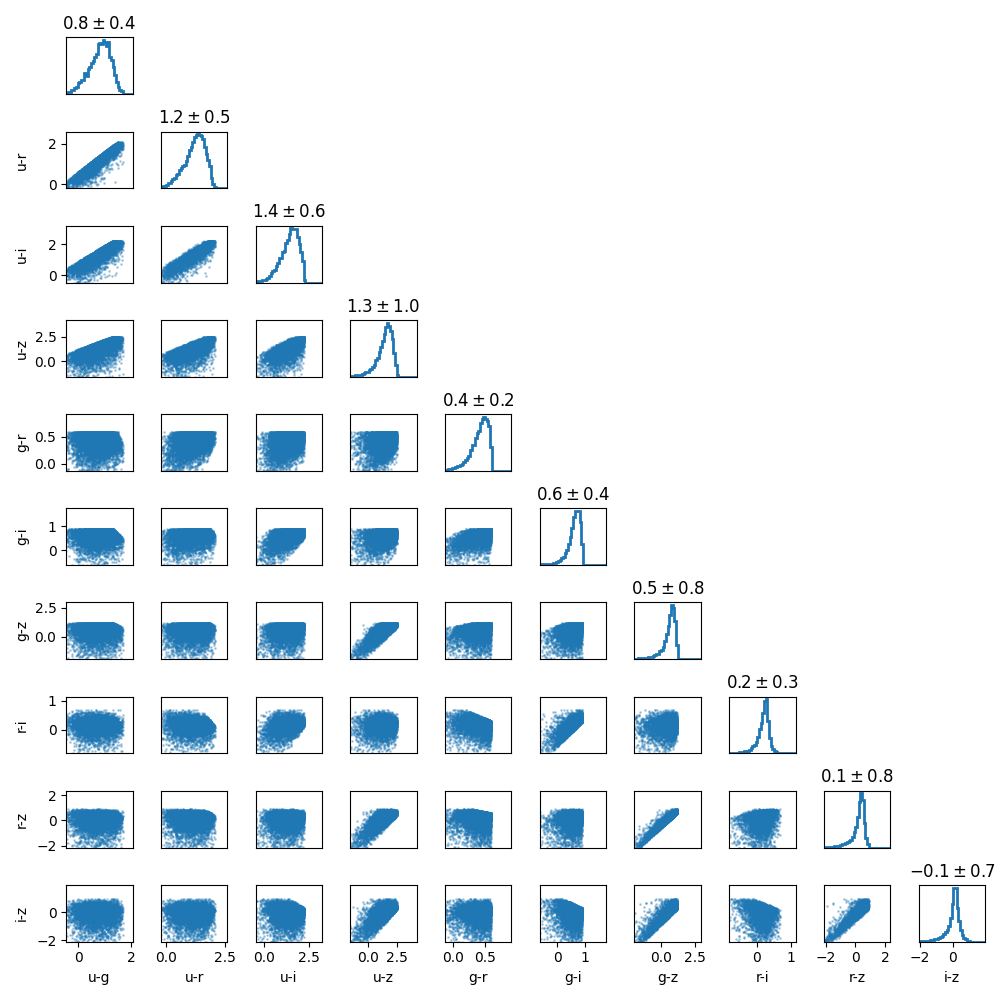
   
**Plot and answer**:

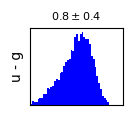

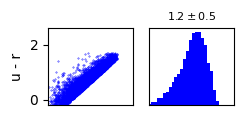

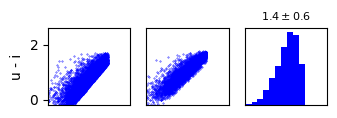

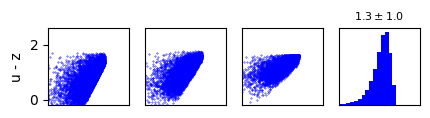

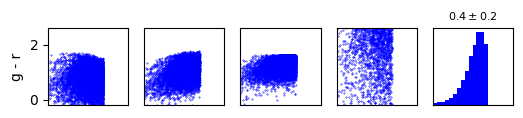

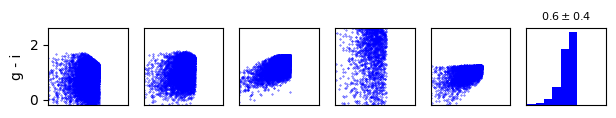

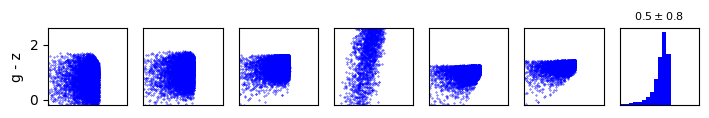

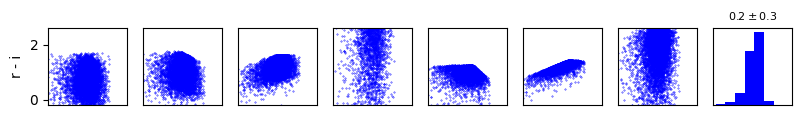

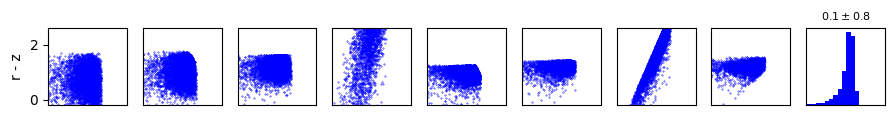

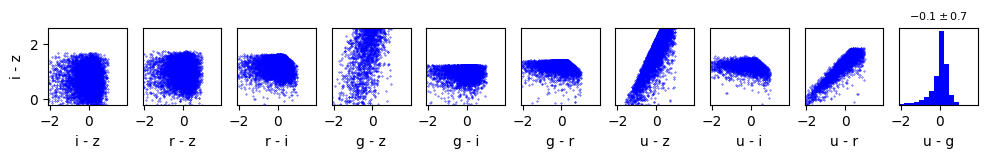

In [170]:
from astropy.io import fits
import numpy as np
import pandas as pd
from astropy.table import Table
import matplotlib.pyplot as plt
#import corner

hdul = fits.open('SDSS_DR17_galaxies.fits')
# from info it was clear I needed the second index for the image data
data = hdul[1].data
df = Table(data).to_pandas() 

filt = df[(df[['u','g','r','i','z']] >= 0).all(axis=1)]

index = ['u','g','r','i','z']
indices = ['u - g', 'u - r', 'u - i', 'u - z', 'g - r', 'g - i', 'g - z', 'r - i', 'r - z', 'i - z']
for i in range(0, len(index)):
    for j in range(i + 1, 5):
        filt[f'{index[i]} - {index[j]}'] = filt[index[i]] - filt[index[j]]
        
# creating ticks and subplots       
for i in range(1, 11):
    fig, frame = plt.subplots(1, i, figsize = (1.2 * i , 1))
    if i == 1:
        frame.set_yticks([])
        frame.set_xticks([])
        frame.set_ylabel(f'{indices[i - 1]}')
    elif 1 < i < 10:
        for j in range(1, i):
            frame[i - j].set_xticks([])
            frame[i - j].set_yticks([])
            frame[0].set_xticks([])
            frame[0].set_ylabel(f'{indices[i - 1]}')
    elif i == 10:
            for j in range(1, i):
                frame[i - j].set_yticks([])
            for j in range(1, i + 1):
                frame[i - j].set_xlabel(f'{indices[j - 1]}')
                frame[0].set_ylabel(f'{indices[i - 1]}')
                
    # creating the plots
    if i == 1:
        frame.hist(filt[indices[i-1]], bins = 100, color = 'blue')
        mean = np.mean(filt[indices[i - 1]])
        std = np.std(filt[indices[i - 1]])
        frame.set_xlim(mean - 3 * std, mean + 3 * std)
        frame.set_title(f'${mean: .1f} \pm {std: .1f}$', fontsize = 8)
    for j in range(1, i):
        frame[j - 1].scatter(filt[indices[i - 1]], filt[indices[j - 1]], s = 0.1, color = 'blue')
        frame[-1].hist(filt[indices[i - 1]], bins = 50, color = 'blue')
        meanx = np.mean(filt[indices[i - 1]])
        stdx = np.std(filt[indices[i - 1]])
        frame[j - 1].set_xlim(meanx - 3 * stdx, meanx + 3 * stdx)
        frame[-1].set_xlim(meanx - 3 * stdx, meanx + 3 * stdx)
        meany = np.mean(filt[indices[j]])
        stdy = np.std(filt[indices[j]])
        frame[-1].set_title(f'${meanx: .1f} \pm {stdx: .1f}$', fontsize = 8)
        if j != i:
            frame[j - 1].set_ylim(meany - 3 * stdy, meany + 3 * stdy)

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

![M77.png](attachment:ad565bb5-5f92-4c74-a96a-5cc7a9a786f2.png)

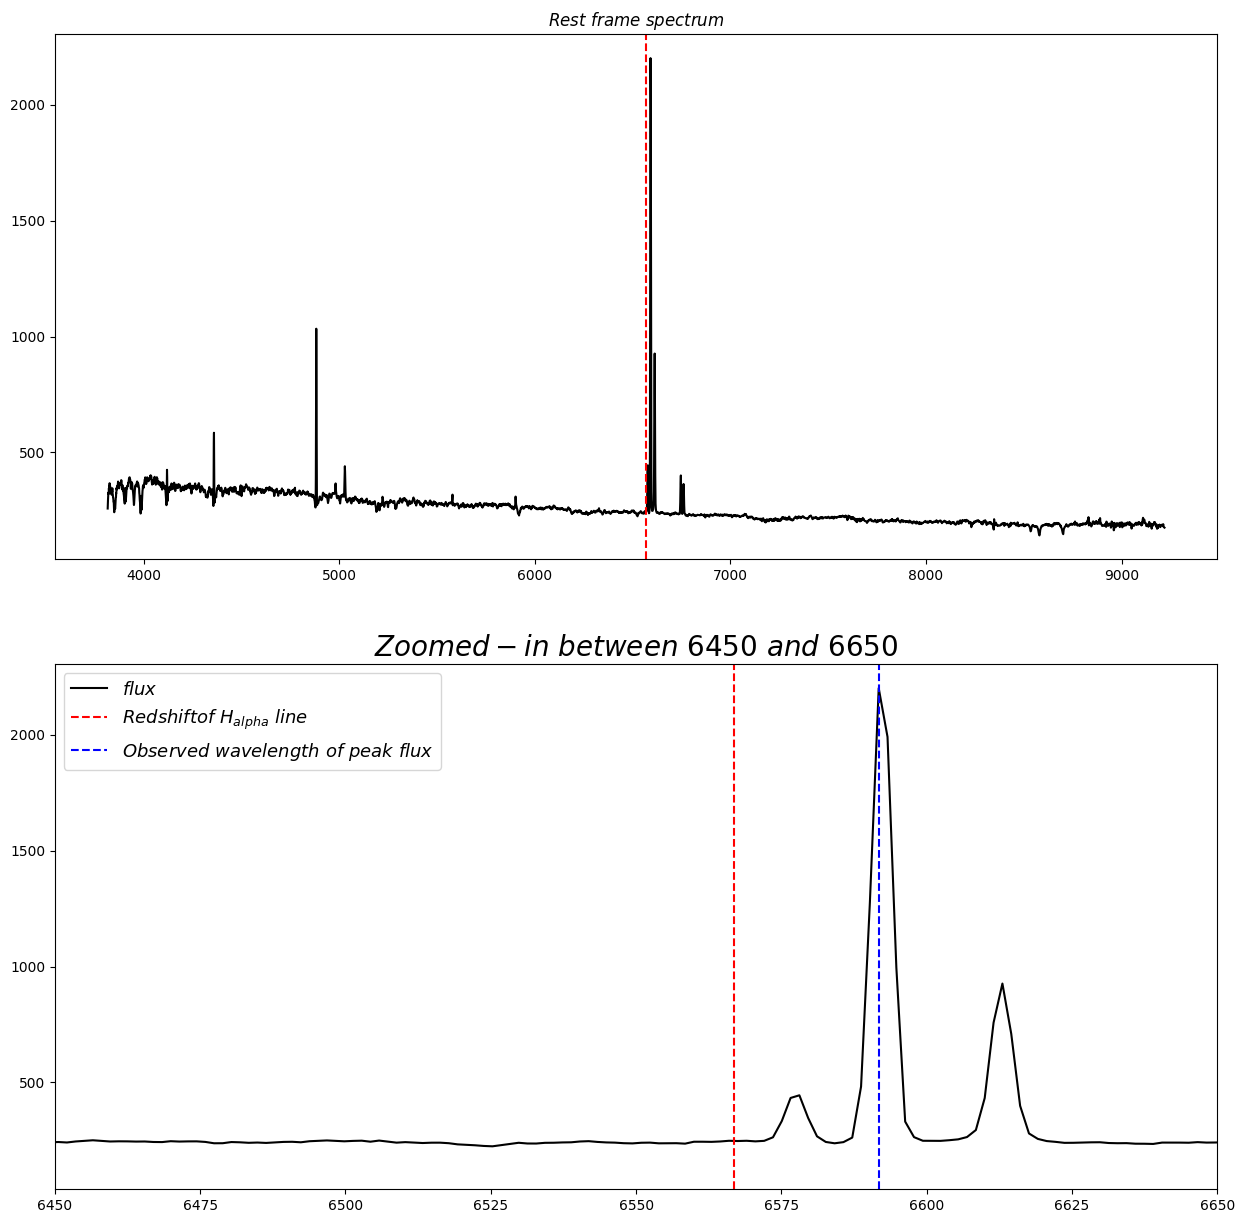

The velocity is 1139240.0 m/s
The velocity is 1139240.0000000112 m/s


In [236]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np
c = 2.998e8

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

info = SDSS.get_spectra(pos, 10 * u.arcsec)
hdulist = info[0]
info = hdulist[1].data

flux = info['flux']
loglam = 10**info['loglam'] # back to linear
peak_index = np.argmax(flux) # index of maximum flux
peak_wavelength = loglam[peak_index]

# plotting
z = 0.0038
fig, frame = plt.subplots(2, 1, figsize = (15, 15))
frame[0].set_title('$Rest\ frame\ spectrum$')
frame[0].plot(loglam, flux, color = 'k')
frame[0].axvline(peak_wavelength / (1 + z), color = 'r', linestyle = '--', label = '$Redshift$')

frame[1].set_title('$Zoomed-in\ between\ 6450\ and\ 6650$', fontsize = 20)
frame[1].plot(loglam, flux, color = 'k', label = '$flux$')
frame[1].axvline(peak_wavelength / (1 + z), color = 'r', linestyle = '--', label = '$Redshift of\ H_{alpha}\ line$')
frame[1].axvline(peak_wavelength, color = 'b', linestyle = '--', label = '$Observed\ wavelength\ of\ peak\ flux$')
frame[1].set_xlim(6450, 6650)
plt.legend(fontsize = 13)
plt.show()

print(f'The velocity is {(peak_wavelength - peak_wavelength / (1 + z)) /(peak_wavelength / (1 + z)) * c} m/s')

I think most of this redshift will be caused by the expansion of the universe. The number is too high to realistically happen I think. In that case I wonder if the expansion of the universe is slower than the speed of light or whether it equal or faster. If it's faster, what happens with light in that case? Are there a few places without even light? And if it's slower I wonder what happens if light reaches the edge of the universe. Does it reflect or get absorbed or get transported to the other end of the universe or break through some fifth dimension or parallel universe?

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/astropy/visualization/stretch.py:555: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)


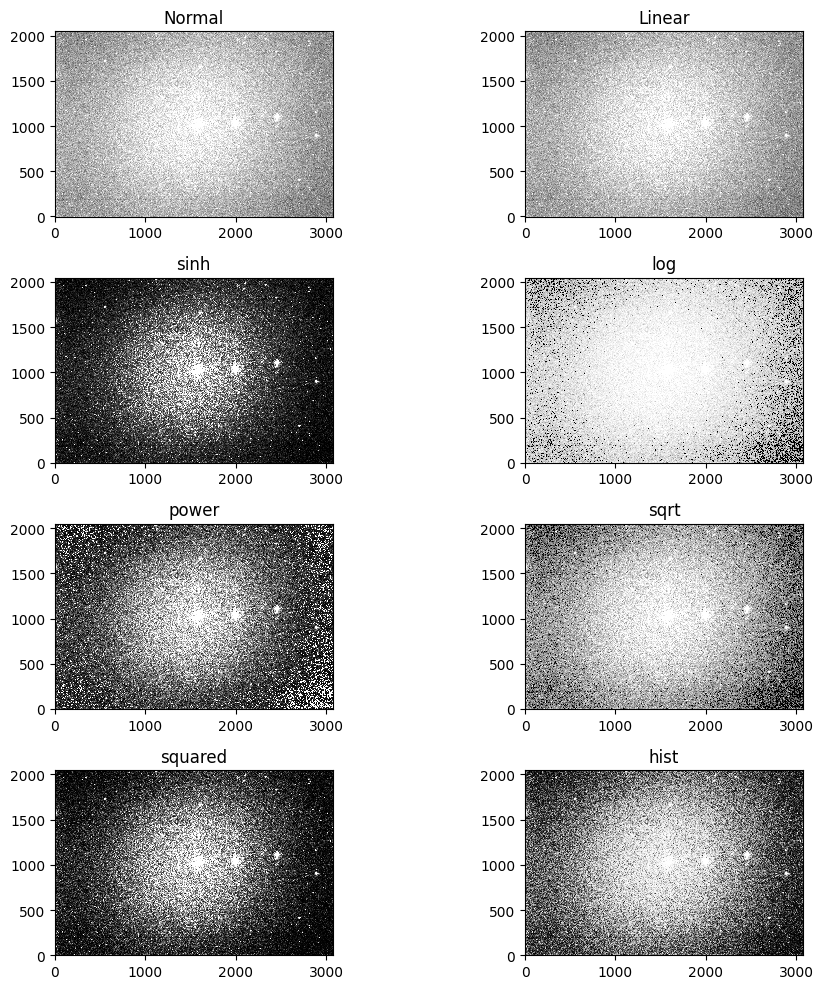

In [4]:
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

data = fits.open('20210422_Li_.00000066.FIT')
data = data[0].data
data = np.asarray(data)
data = np.array(data, dtype=float)

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    '''Function plotting everything but the top and bottom percent of pixels. Standard scale is linear. other scales enhance other points of the data
    like how log emphasises the lower values. The cmap determines the color palette of the image, where zscale means that the function determines a
    a suitable range for the values in the image. Vmin and vmax do what zscale does manually. Power determines how the pixel brightness is distributed.
    kwargs means this function also accepts other key word arguments which aren't given in the function'''
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


fig, ax = plt.subplots(4, 2, figsize = (10, 10))
imdisplay(data, ax[0, 0], percentlow=5, percenthigh=95)
ax[0, 0].set_title('Normal')
imdisplay(data, ax[0, 1], percentlow=5, percenthigh=95, scale='linear')
ax[0, 1].set_title('Linear')
imdisplay(data, ax[1, 0], percentlow=5, percenthigh=95, scale='sinh')
ax[1, 0].set_title('sinh')
imdisplay(data, ax[1, 1], percentlow=5, percenthigh=95, scale='log')
ax[1, 1].set_title('log')
imdisplay(data, ax[2, 0], percentlow=5, percenthigh=95, scale='power')
ax[2, 0].set_title('power')
imdisplay(data, ax[2, 1], percentlow=5, percenthigh=95, scale='sqrt')
ax[2, 1].set_title('sqrt')
imdisplay(data, ax[3, 0], percentlow=5, percenthigh=95, scale='squared')
ax[3, 0].set_title('squared')
imdisplay(data, ax[3, 1], percentlow=5, percenthigh=95, scale='hist')
ax[3, 1].set_title('hist')
plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

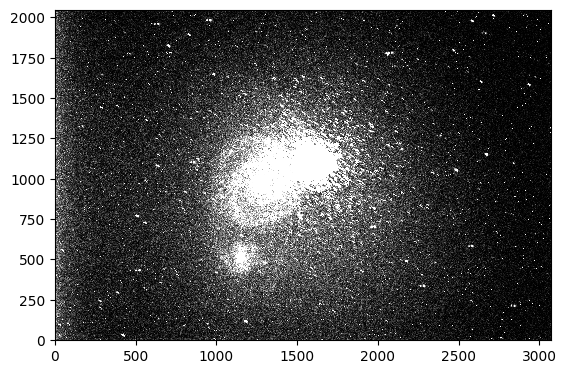

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from math import ceil
from astropy.io import fits
import numpy as np

path = Path("/Users/users/lkmispelaar/DATA/")
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in ['BIAS', 'FLAT', 'DARK']):
            filepaths.append(filepath)

images = []
for filepath in filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()
    
fig, ax = plt.subplots()
imdisplay(np.median(np.stack(images), axis=0), ax, percentlow=5, percenthigh=95, scale='squared')
plt.show()

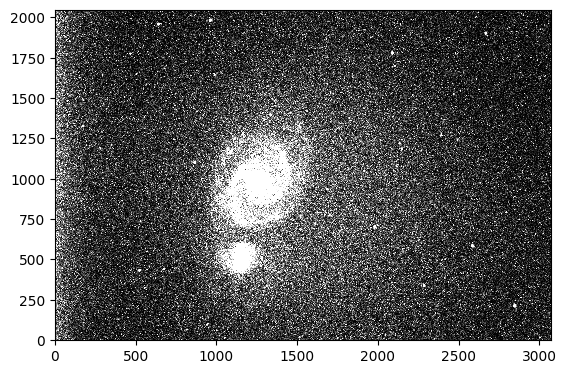

In [12]:
from matplotlib.pyplot import subplots, show
import astroalign as aa

hdulist = fits.open(filepaths[6])
target_im = hdulist[0].data.astype('float')
hdulist = fits.open(filepaths[4])
tobealigned_im = hdulist[0].data.astype('float')

aligned_im, footprint = aa.register(tobealigned_im, target_im, detection_sigma=3.0)

fig, ax = subplots()
imdisplay(aligned_im, ax, percentlow=5, percenthigh=95, scale='squared')
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")